In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import time

from data_prep import get_adult_data, get_german_data
from models_for_comparison import BinClassRO, evaluate_BinClassRO
from PostProc import PostProc
from evaluation_measures import eval_risk, eval_RejectOption, eval_DP
from evaluation import evaluate_reject_option
from plots import plot_compare

# Experiments on Adult dataset

In [44]:
DATASET = 'adult'
NUM = 10
ALPHA_LIST = [0.2, 0.1, 0.05, 0.025, 0.0125]
# ALPHA_LIST = []
# i_list  = [1, 2, 4, 5, 6, 8, 16, 32, 128, 512]
# for i in i_list:
#     ALPHA_LIST+=[2**(-i)]
K = 2
T = 800
results_PostProc_adult_800 = evaluate_reject_option(dataset=DATASET, num=NUM, K=K, T=T, alpha_list=ALPHA_LIST, 
                            print_details = True, beta='auto', L='auto',
                            alg={'base':'SGD3', 'method':'ACSA2'},
                            TRAIN_SIZE=0.4, UNLAB_SIZE=0.4, TEST_SIZE=0.2, data_scaling=True)
results_PostProc_adult_800    

1 / 5  : collecting statistics for alpha=0.2
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : training completed, statistics collected
-----    6 / 10 : training completed, statistics collected
-----    7 / 10 : training completed, statistics collected
-----    8 / 10 : training completed, statistics collected
-----    9 / 10 : training completed, statistics collected
-----    10 / 10 : training completed, statistics collected
---------------------------------------------------------
2 / 5  : collecting statistics for alpha=0.1
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : trainin

{'risk': {'mean': [0.1619870511636266,
   0.16198705116362666,
   0.16198705116362666,
   0.16198705116362666,
   0.16198705116362666],
  'std': [0.028279413103071697,
   0.028279413103071704,
   0.028279413103071704,
   0.028279413103071704,
   0.028279413103071704]},
 'constraint': {'mean': [5.5334068015202424e-17,
   2.8340087082755082e-34,
   4.467832675563502e-46,
   6.211196773590911e-53,
   1.1072009647304605e-56],
  'std': [1.6114516931374754e-17,
   7.256362825572549e-35,
   1.474207639928994e-46,
   1.28867735057429e-53,
   1.576676418926989e-57]},
 'base_risk': {'mean': 0.22433504504179616, 'std': 0.01683415777439591},
 'risk_argmax': {'mean': [0.16299999999999998,
   0.16299999999999998,
   0.16299999999999998,
   0.16299999999999998,
   0.16299999999999998],
  'std': [0.02749545416973504,
   0.02749545416973504,
   0.02749545416973504,
   0.02749545416973504,
   0.02749545416973504]},
 'constraint_argmax': {'mean': [0.0, 0.0, 0.0, 0.0, 0.0],
  'std': [0.0, 0.0, 0.0, 0.0, 0

In [6]:
DATASET = 'adult'
NUM = 10
ALPHA_LIST = [0.2, 0.1, 0.05, 0.025, 0.0125]
# ALPHA_LIST = []
# i_list  = [1, 2, 4, 5, 6, 8, 16, 32, 128, 512]
# for i in i_list:
#     ALPHA_LIST+=[2**(-i)]
K = 2
T = 100
results_PostProc_adult = evaluate_reject_option(dataset=DATASET, num=NUM, K=K, T=T, alpha_list=ALPHA_LIST, 
                            print_details = True, beta='auto', L='auto',
                            alg={'base':'SGD3', 'method':'ACSA2'},
                            TRAIN_SIZE=0.4, UNLAB_SIZE=0.4, TEST_SIZE=0.2, data_scaling=True)
results_PostProc_adult                            

1 / 5  : collecting statistics for alpha=0.2
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : training completed, statistics collected
-----    6 / 10 : training completed, statistics collected
-----    7 / 10 : training completed, statistics collected
-----    8 / 10 : training completed, statistics collected
-----    9 / 10 : training completed, statistics collected
-----    10 / 10 : training completed, statistics collected
---------------------------------------------------------
2 / 5  : collecting statistics for alpha=0.1
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : trainin

{'risk': {'mean': [0.08510164680192553,
   0.13915583663942457,
   0.1604901723406666,
   0.16175254321828206,
   0.1618952659410873],
  'std': [0.018983105667206884,
   0.025291739604522013,
   0.02823659264795113,
   0.02827155919130712,
   0.028282088901189446]},
 'constraint': {'mean': [0.19251458395392684,
   0.04698472701378935,
   0.003007813550522042,
   0.00046925628108359556,
   0.0001850629990484656],
  'std': [0.015594995309616678,
   0.008070465018143177,
   0.0006516882435698406,
   0.00011764684694992518,
   3.663907878649859e-05]},
 'base_risk': {'mean': 0.22433504504179616, 'std': 0.01683415777439591},
 'risk_argmax': {'mean': [0.08499999999999999,
   0.138,
   0.16299999999999998,
   0.16299999999999998,
   0.16299999999999998],
  'std': [0.020124611797498106,
   0.026758176320519304,
   0.02749545416973504,
   0.02749545416973504,
   0.02749545416973504]},
 'constraint_argmax': {'mean': [0.189, 0.0475, 0.0, 0.0, 0.0],
  'std': [0.02071231517720798, 0.0122983738762488

In [4]:
results_BinClassRO_adult = {'risk': {'mean': [0.1659119173129479,
   0.1659119173129479,
   0.1659119173129479,
   0.1659119173129479,
   0.1659119173129479],
  'std': [0.011640817085601357,
   0.011640817085601357,
   0.011640817085601357,
   0.011640817085601357,
   0.011640817085601357]},
 'constraint': {'mean': [0.48878749999999993,
   0.48878749999999993,
   0.48878749999999993,
   0.48878749999999993,
   0.48878749999999993],
  'std': [0.014025014483058462,
   0.014025014483058462,
   0.014025014483058462,
   0.014025014483058462,
   0.014025014483058462]},
 'base_risk': {'mean': 0.22433504504179616, 'std': 0.01683415777439591},
 'risk_clf': {'mean': [0.07899999999999999,
   0.1135,
   0.13099999999999998,
   0.144,
   0.14899999999999997],
  'std': [0.018681541692269408,
   0.024295061226512687,
   0.030724582991474434,
   0.03433656942677879,
   0.034117444218463966]},
 'constraint_clf': {'mean': [0.20700000000000002,
   0.10900000000000001,
   0.0655,
   0.0355,
   0.026500000000000003],
  'std': [0.0212367605815953,
   0.025475478405713993,
   0.02126617031813674,
   0.020303940504246953,
   0.018980252896102306]},
 'base_risk_clf': {'mean': 0.163, 'std': 0.02749545416973504},
 'training_time_hist': [0.0,
  0.003306865692138672,
  0.0010461807250976562,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0015902519226074219,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.00027489662170410156,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.006504058837890625,
  0.0,
  0.0,
  0.004502534866333008,
  0.0,
  0.0,
  0.0]}

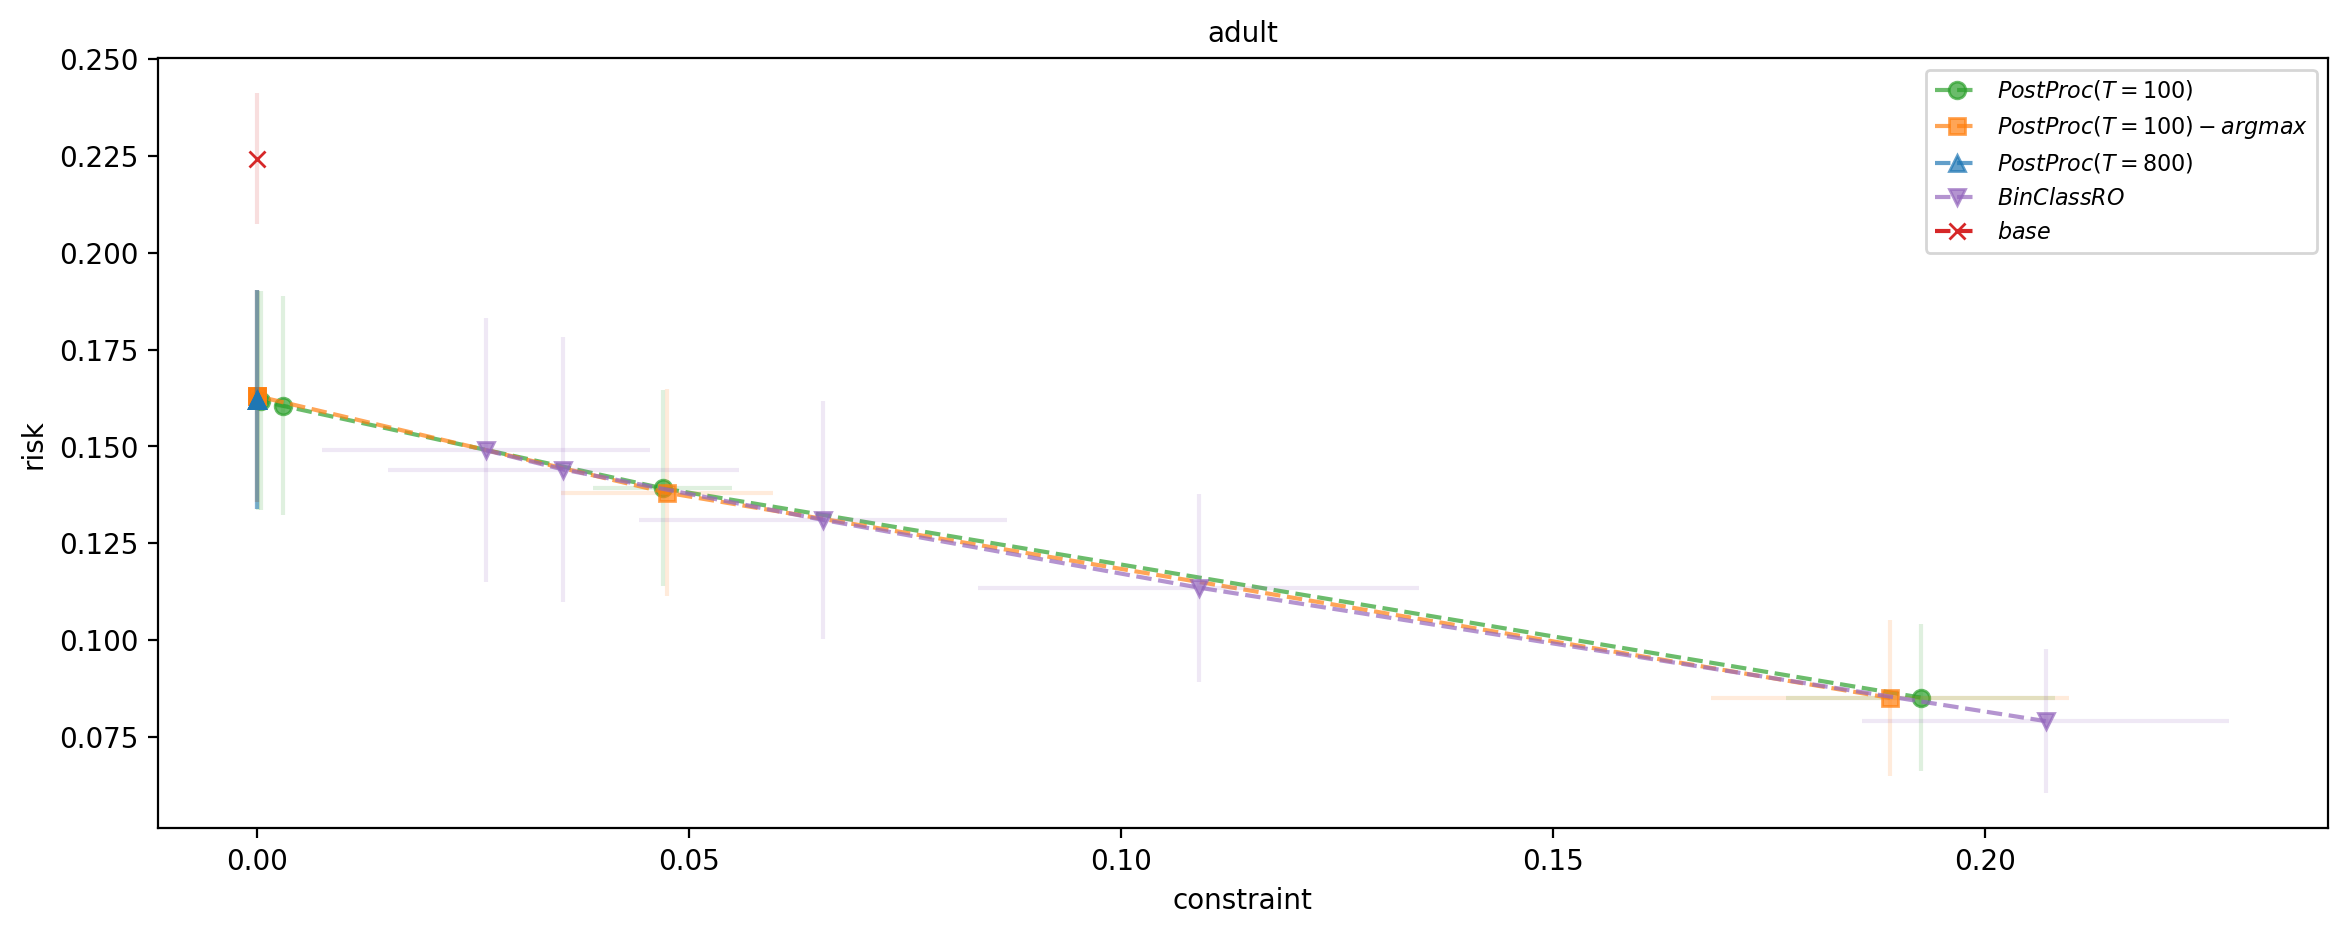

In [45]:
base_constraint={'mean': 0, 'std': 0}
pairs_list = [[results_PostProc_adult['constraint'], results_PostProc_adult['risk']],
              [results_PostProc_adult['constraint_argmax'], results_PostProc_adult['risk_argmax']],
              [results_PostProc_adult_800['constraint'], results_PostProc_adult_800['risk']],
              [results_BinClassRO_adult['constraint_clf'], results_BinClassRO_adult['risk_clf']],
              [base_constraint, results_PostProc_adult['base_risk']]]
model_list = [r'$PostProc (T=100)$',r'$PostProc  (T=100)-argmax$',r'$PostProc (T=800)$',r'$BinClassRO$',r'$base$']
markers_list = ['o', 's','^','v','x']
dataset='adult'
colors=['tab:green','tab:orange','tab:blue','tab:purple', 'tab:red']

plot_compare(pairs_list=pairs_list, model_list=model_list,
                          markers_list=markers_list, dataset=dataset, 
                          x_label = 'constraint', y_label = 'risk',
                          colors = colors, legend_size=8, alpha=0.7, 
                          plot_std=True, annotate=False, loglog=False, start_0=False, linestyle='dashed')

# Experiments on German data

In [41]:
DATASET = 'german'
NUM = 10
ALPHA_LIST = [0.2, 0.1, 0.05, 0.025, 0.0125]
K = 2
T = 400
results_PostProc_german_400 = evaluate_reject_option(dataset=DATASET, num=NUM, K=K, T=T, alpha_list=ALPHA_LIST, 
                            print_details = True, beta='auto', L='auto',
                            alg={'base':'SGD3', 'method':'ACSA'},
                            TRAIN_SIZE=0.4, UNLAB_SIZE=0.4, TEST_SIZE=0.2, data_scaling=True)
results_PostProc_german_400       

1 / 5  : collecting statistics for alpha=0.2
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : training completed, statistics collected
-----    6 / 10 : training completed, statistics collected
-----    7 / 10 : training completed, statistics collected
-----    8 / 10 : training completed, statistics collected
-----    9 / 10 : training completed, statistics collected
-----    10 / 10 : training completed, statistics collected
---------------------------------------------------------
2 / 5  : collecting statistics for alpha=0.1
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : trainin

{'risk': {'mean': [0.2850810285699021,
   0.28508103101799,
   0.28508103101799065,
   0.28508103101799065,
   0.28508103101799065],
  'std': [0.0400123255563413,
   0.04001232555889556,
   0.04001232555889555,
   0.04001232555889555,
   0.04001232555889555]},
 'constraint': {'mean': [4.8183123953350074e-09,
   1.2448732916463208e-15,
   3.7660329427598006e-19,
   5.349891800676242e-21,
   6.488102584001385e-22],
  'std': [1.826662520673881e-09,
   5.102119069383649e-16,
   1.6006546952013237e-19,
   2.1076298263245155e-21,
   2.849013405343654e-22]},
 'base_risk': {'mean': 0.3464468032429629, 'std': 0.023643912510089633},
 'risk_argmax': {'mean': [0.28600000000000003,
   0.28600000000000003,
   0.28600000000000003,
   0.28600000000000003,
   0.28600000000000003],
  'std': [0.03852272056851645,
   0.03852272056851645,
   0.03852272056851645,
   0.03852272056851645,
   0.03852272056851645]},
 'constraint_argmax': {'mean': [0.0, 0.0, 0.0, 0.0, 0.0],
  'std': [0.0, 0.0, 0.0, 0.0, 0.0]},
 

In [39]:
DATASET = 'german'
NUM = 10
ALPHA_LIST = [0.2, 0.1, 0.05, 0.025, 0.0125]
K = 2
T = 100
results_PostProc_german = evaluate_reject_option(dataset=DATASET, num=NUM, K=K, T=T, alpha_list=ALPHA_LIST, 
                            print_details = True, beta='auto', L='auto',
                            alg={'base':'SGD3', 'method':'ACSA'},
                            TRAIN_SIZE=0.4, UNLAB_SIZE=0.4, TEST_SIZE=0.2, data_scaling=True)
results_PostProc_german         

1 / 5  : collecting statistics for alpha=0.2
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : training completed, statistics collected
-----    6 / 10 : training completed, statistics collected
-----    7 / 10 : training completed, statistics collected
-----    8 / 10 : training completed, statistics collected
-----    9 / 10 : training completed, statistics collected
-----    10 / 10 : training completed, statistics collected
---------------------------------------------------------
2 / 5  : collecting statistics for alpha=0.1
-----    1 / 10 : training completed, statistics collected
-----    2 / 10 : training completed, statistics collected
-----    3 / 10 : training completed, statistics collected
-----    4 / 10 : training completed, statistics collected
-----    5 / 10 : trainin

{'risk': {'mean': [0.13187317778668933,
   0.2135090110952087,
   0.2522990088474534,
   0.26703493334089573,
   0.27282317820231655],
  'std': [0.020733696419646157,
   0.033549339416242344,
   0.03802776497777244,
   0.03923627092191285,
   0.039525368478721006]},
 'constraint': {'mean': [0.36375863183323265,
   0.14887780192656036,
   0.06537934876441523,
   0.03561901459236277,
   0.024189311242749718],
  'std': [0.033621897211342386,
   0.02757144985758304,
   0.017981910456895248,
   0.01118678966855305,
   0.00815057157654176]},
 'base_risk': {'mean': 0.3464468032429629, 'std': 0.023643912510089633},
 'risk_argmax': {'mean': [0.13099999999999998,
   0.21500000000000002,
   0.25599999999999995,
   0.27599999999999997,
   0.28600000000000003],
  'std': [0.024269322199023197,
   0.0372155881318568,
   0.03903844259188627,
   0.046303347611160915,
   0.03852272056851645]},
 'constraint_argmax': {'mean': [0.369,
   0.14200000000000002,
   0.05600000000000001,
   0.016,
   0.001],
  '

In [21]:
results_BinClassRO_german = {'risk': {'mean': [0.1659119173129479,
   0.1659119173129479,
   0.1659119173129479,
   0.1659119173129479,
   0.1659119173129479],
  'std': [0.011640817085601357,
   0.011640817085601357,
   0.011640817085601357,
   0.011640817085601357,
   0.011640817085601357]},
 'constraint': {'mean': [0.48878749999999993,
   0.48878749999999993,
   0.48878749999999993,
   0.48878749999999993,
   0.48878749999999993],
  'std': [0.014025014483058462,
   0.014025014483058462,
   0.014025014483058462,
   0.014025014483058462,
   0.014025014483058462]},
 'base_risk': {'mean': 0.22433504504179616, 'std': 0.01683415777439591},
 'risk_clf': {'mean': [0.07899999999999999,
   0.1135,
   0.13099999999999998,
   0.144,
   0.14899999999999997],
  'std': [0.018681541692269408,
   0.024295061226512687,
   0.030724582991474434,
   0.03433656942677879,
   0.034117444218463966]},
 'constraint_clf': {'mean': [0.20700000000000002,
   0.10900000000000001,
   0.0655,
   0.0355,
   0.026500000000000003],
  'std': [0.0212367605815953,
   0.025475478405713993,
   0.02126617031813674,
   0.020303940504246953,
   0.018980252896102306]},
 'base_risk_clf': {'mean': 0.163, 'std': 0.02749545416973504},
 'training_time_hist': [0.0,
  0.0,
  0.007018327713012695,
  0.0,
  0.0025026798248291016,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0019083023071289062,
  0.0,
  0.0,
  0.0,
  0.004214048385620117,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.004018068313598633,
  0.0005102157592773438,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0009644031524658203,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0]}

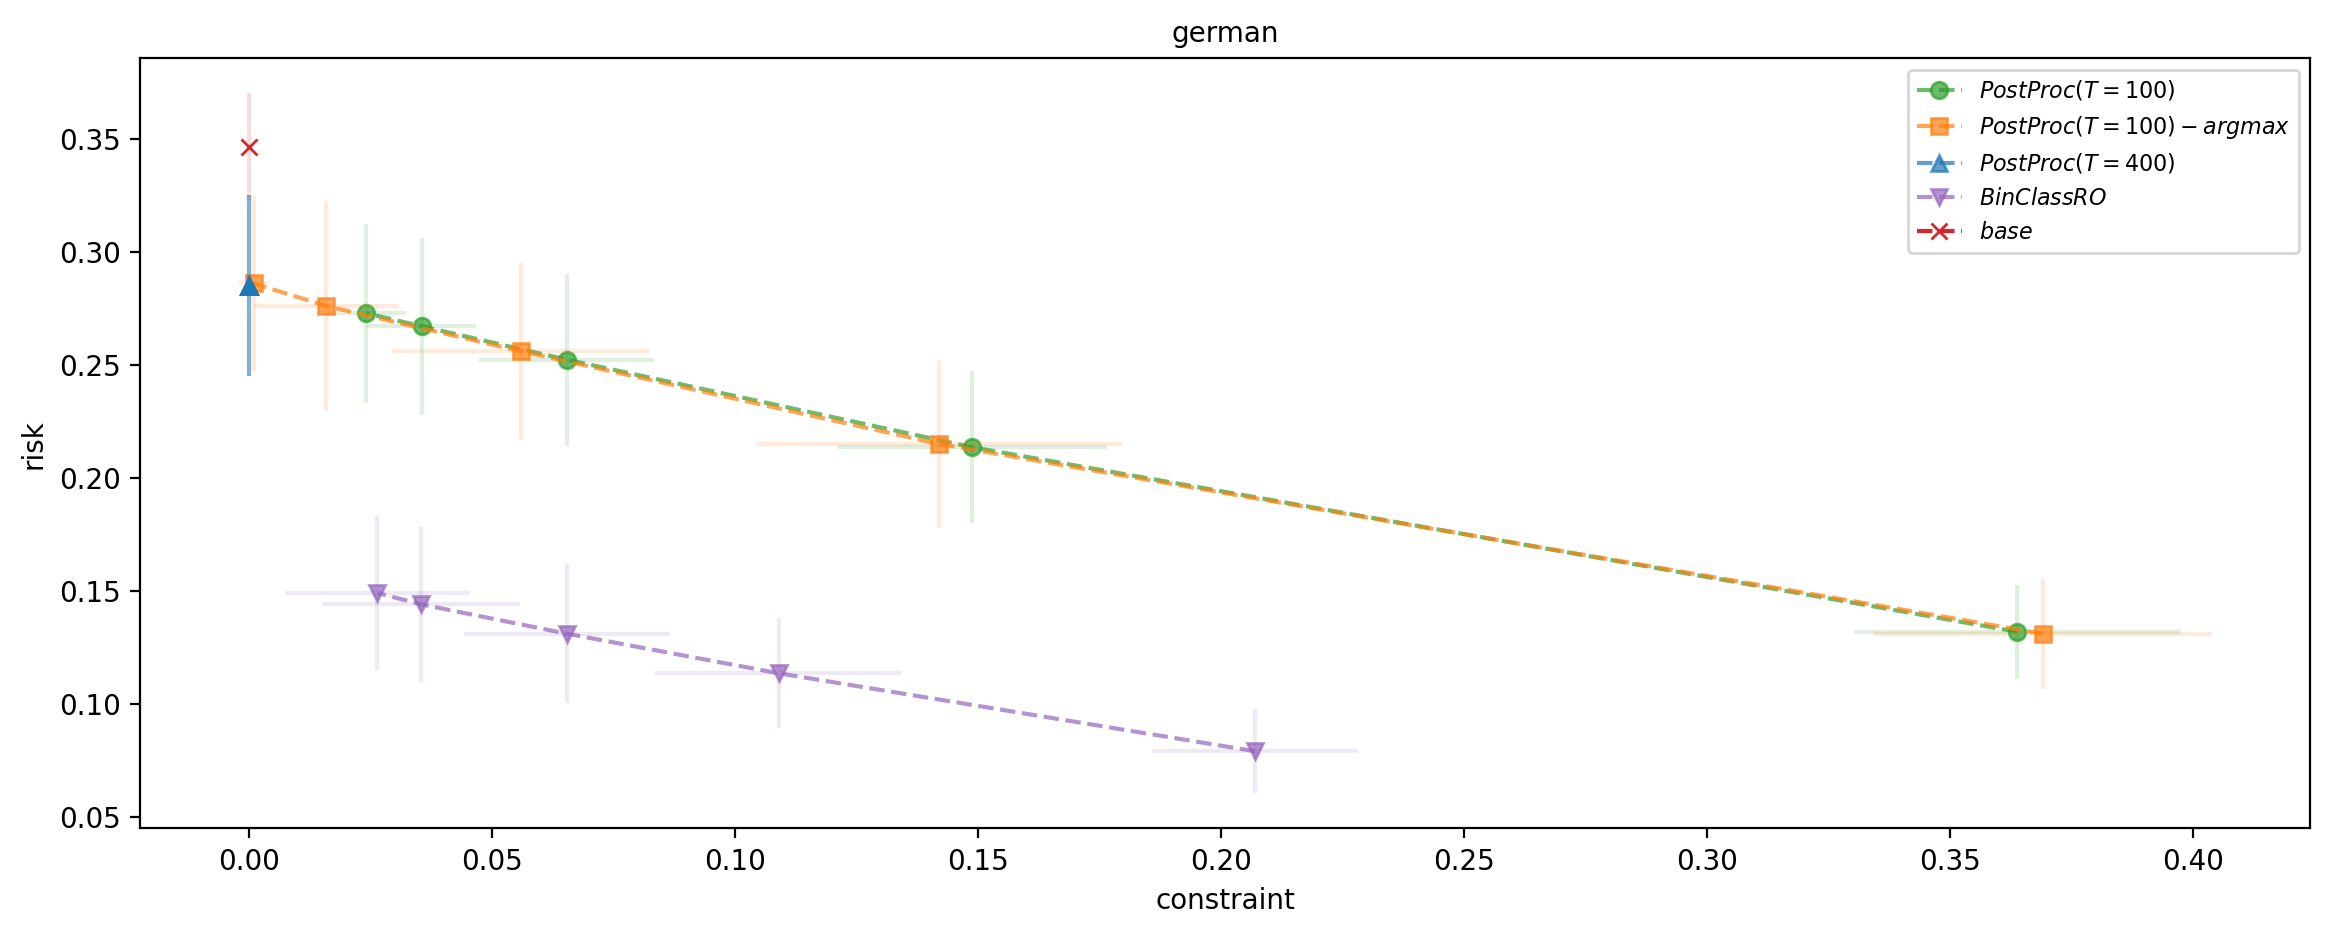

In [43]:
base_constraint={'mean': 0, 'std': 0}
pairs_list = [[results_PostProc_german['constraint'], results_PostProc_german['risk']],
              [results_PostProc_german['constraint_argmax'], results_PostProc_german['risk_argmax']],
              [results_PostProc_german_400['constraint'],results_PostProc_german_400['risk']],
              [results_BinClassRO_german['constraint_clf'], results_BinClassRO_german['risk_clf']],
              [base_constraint, results_PostProc_german['base_risk']]]
model_list = [r'$PostProc (T=100)$',r'$PostProc  (T=100)-argmax$',r'$PostProc (T=400)$',r'$BinClassRO$',r'$base$']
markers_list = ['o', 's','^','v','x']
dataset='german'
colors=['tab:green','tab:orange','tab:blue','tab:purple', 'tab:red']

plot_compare(pairs_list=pairs_list, model_list=model_list,
                        markers_list=markers_list, dataset=dataset, 
                        x_label = 'constraint', y_label = 'risk',
                        colors = colors, legend_size=8, alpha=0.7, 
                        plot_std=True, annotate=False, loglog=False, start_0=False, linestyle='dashed')